✅ Dataset Loaded
Initial Shape: (625783, 86)
Cleaned Shape: (261543, 80)
Final Shape after filtering classes: (261543, 80)
✅ SMOTE Applied
✅ Top 10 MI Features Selected

📊 Model Performance (Top 20 MI Features)

🧠 Random Forest
Train Accuracy: 0.9992
Test Accuracy : 0.9677
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11872
           1       0.76      0.89      0.82      3009
           2       0.99      0.97      0.98     28667
           3       0.99      0.98      0.99      5506
           4       0.87      0.92      0.89      3255

    accuracy                           0.97     52309
   macro avg       0.92      0.95      0.94     52309
weighted avg       0.97      0.97      0.97     52309

--------------------------------------------------
🧠 KNN
Train Accuracy: 0.9671
Test Accuracy : 0.9463
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11872
           1       0.62  

,Train Accuracy,Test Accuracy,Gap
Random Forest,0.999173,0.967654,0.031520
KNN,0.967117,0.946338,0.020779
MLP,0.746457,0.729492,0.016965
XGBoost,0.960415,0.953373,0.007042


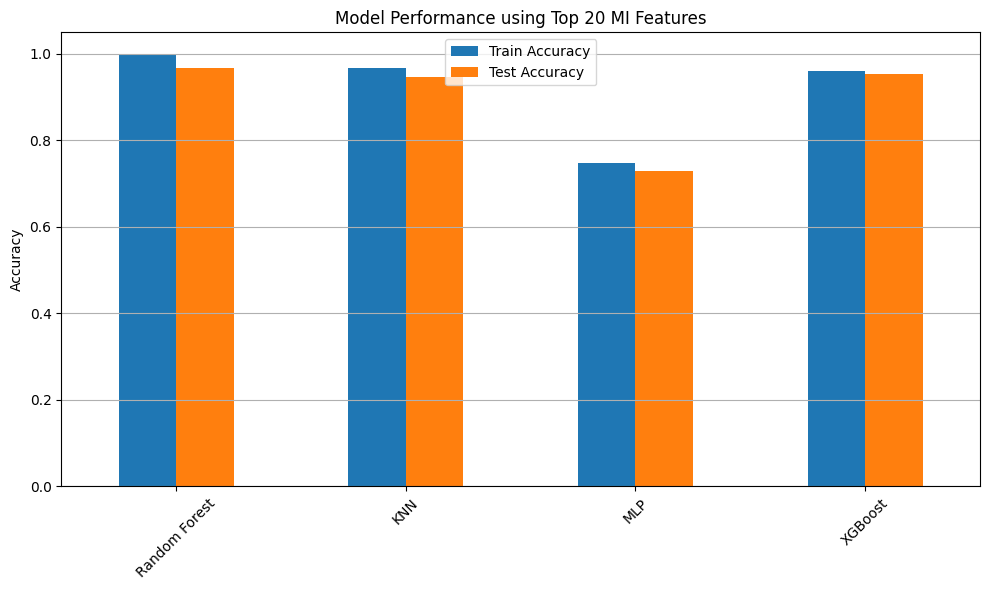

In [1]:
# ===============================
# 1. Suppress Warnings
# ===============================
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 2. Imports
# ===============================
import pandas as pd
import numpy as np

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ===============================
# 3. Load Dataset
# ===============================
df = pd.read_csv('/content/IoT Network Intrusion Dataset.csv')
print("✅ Dataset Loaded")
print(f"Initial Shape: {df.shape}")

# ===============================
# 4. Drop Unwanted Columns
# ===============================
drop_cols = ['Flow_ID', 'Src_IP', 'Dst_IP', 'Timestamp', 'Label', 'Sub_Cat']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ===============================
# 5. Handle Missing & Infinite Values
# ===============================
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

print(f"Cleaned Shape: {df.shape}")

# ===============================
# 6. Encode Target
# ===============================
le = LabelEncoder()
df['Cat'] = le.fit_transform(df['Cat'])

X = df.drop('Cat', axis=1)
y = df['Cat']

# ===============================
# 7. Remove Minority Classes (<2 samples)
# ===============================
class_counts = y.value_counts()
minority_classes = class_counts[class_counts < 2].index

if len(minority_classes) > 0:
    df = df[~df['Cat'].isin(minority_classes)]
    le = LabelEncoder()
    df['Cat'] = le.fit_transform(df['Cat'])

X = df.drop('Cat', axis=1)
y = df['Cat']

print(f"Final Shape after filtering classes: {df.shape}")

# ===============================
# 8. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===============================
# 9. Apply SMOTE (Training Only)
# ===============================
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Applied")

# ===============================
# 10. Mutual Information (Top 20 Features)
# ===============================
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

TOP_K = 10
top_features = mi_series.head(TOP_K).index.tolist()

print(f"✅ Top {TOP_K} MI Features Selected")

X_train_mi = X_train_bal[top_features]
X_test_mi = X_test[top_features]

# ===============================
# 11. Models
# ===============================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
}

# ===============================
# 12. Train & Evaluate
# ===============================
results = {}

print("\n📊 Model Performance (Top 20 MI Features)\n")

for name, model in models.items():
    model.fit(X_train_mi, y_train_bal)

    y_train_pred = model.predict(X_train_mi)
    y_test_pred = model.predict(X_test_mi)

    train_acc = accuracy_score(y_train_bal, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    }

    print(f"🧠 {name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(classification_report(y_test, y_test_pred))
    print("-" * 50)

# ===============================
# 13. Overfitting Analysis
# ===============================
results_df = pd.DataFrame(results).T
results_df["Gap"] = results_df["Train Accuracy"] - results_df["Test Accuracy"]

print("\n📉 Overfitting Check")
display(results_df.sort_values("Gap", ascending=False))

# ===============================
# 14. Visualization
# ===============================
results_df[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', figsize=(10,6)
)
plt.title("Model Performance using Top 20 MI Features")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()